IMPORTING PACKAGES

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

LOAD DATA

In [5]:
l= pd.read_csv(r"C:\Users\aasth\Downloads\loan-default-risk-analysis-vjfdl\loan_applications.csv")
b= pd.read_csv(r"C:\Users\aasth\Downloads\loan-default-risk-analysis-vjfdl\borrower_profiles.csv")

INSPECT THE DATA

In [ ]:
l.head()
b.head()
l.columns
print(l.dtypes)
print("*************")
print(b.dtypes)
print(l.shape)
print(b.shape)

loan_id                     object
borrower_id                 object
application_date    datetime64[ns]
loan_purpose                object
loan_amount                float64
term_months                  int64
interest_rate              float64
monthly_payment            float64
dti_ratio                  float64
loan_status                 object
days_delinquent              int64
defaulted                    int64
dtype: object
*************
borrower_id              object
age                       int64
state                    object
education_level          object
employment_status        object
years_employed            int64
annual_income             int64
credit_score              int64
home_ownership           object
dependents                int64
existing_monthly_debt     int64
dtype: object
(601, 12)
(500, 11)
<bound method DataFrame.info of       loan_id borrower_id application_date      loan_purpose  loan_amount  \
0    LN-00001    BRW-0001       2024-01-08          Vacat

In [14]:
l['application_date']= pd.to_datetime(l['application_date'])
l.dtypes

loan_id                     object
borrower_id                 object
application_date    datetime64[ns]
loan_purpose                object
loan_amount                float64
term_months                  int64
interest_rate              float64
monthly_payment            float64
dti_ratio                  float64
loan_status                 object
days_delinquent              int64
defaulted                    int64
dtype: object

In [19]:
l.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   loan_id           601 non-null    object        
 1   borrower_id       601 non-null    object        
 2   application_date  601 non-null    datetime64[ns]
 3   loan_purpose      601 non-null    object        
 4   loan_amount       601 non-null    float64       
 5   term_months       601 non-null    int64         
 6   interest_rate     601 non-null    float64       
 7   monthly_payment   601 non-null    float64       
 8   dti_ratio         601 non-null    float64       
 9   loan_status       601 non-null    object        
 10  days_delinquent   601 non-null    int64         
 11  defaulted         601 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 56.5+ KB


In [20]:
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [21]:
l.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [22]:
b.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [31]:
# Missing values
l.isnull().sum()
b.isnull().sum()
len(b)

500

In [29]:
missing_pct = (
    l.isnull().sum()
    / len(l)
    * 100
).sort_values(ascending=False)

print(missing_pct)

loan_id             0.0
borrower_id         0.0
application_date    0.0
loan_purpose        0.0
loan_amount         0.0
term_months         0.0
interest_rate       0.0
monthly_payment     0.0
dti_ratio           0.0
loan_status         0.0
days_delinquent     0.0
defaulted           0.0
dtype: float64


In [34]:
# Duplicate values
l.duplicated().sum()
b.duplicated().sum()

0

In [36]:
l['defaulted'].value_counts(normalize=True)*100

0    75.707155
1    24.292845
Name: defaulted, dtype: float64

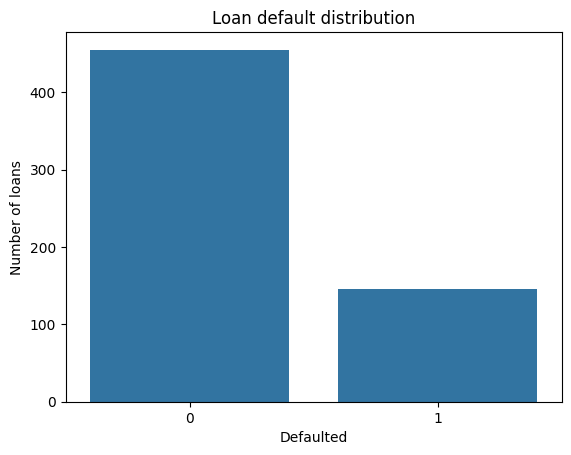

In [37]:
sns.countplot(data=l,x='defaulted')
plt.title("Loan default distribution")
plt.xlabel('Defaulted')
plt.ylabel('Number of loans')
plt.show()

DTI vs DEFAULT RATE

In [40]:
l['dti category']=pd.cut(
    l['dti_ratio'],
    bins=[-np.inf,20,40,60,80,np.inf],
    labels=['Very low(<20)', 'low(20-40)','moderate(40-60)','high(60-80)','Very high(>80)']
)
dti_default= (l.groupby('dti category',observed=True)['defaulted']
                .mean().mul(100))
dti_default


dti category
Very low(<20)      16.666667
low(20-40)         12.169312
moderate(40-60)    27.979275
high(60-80)        35.294118
Very high(>80)     36.538462
Name: defaulted, dtype: float64

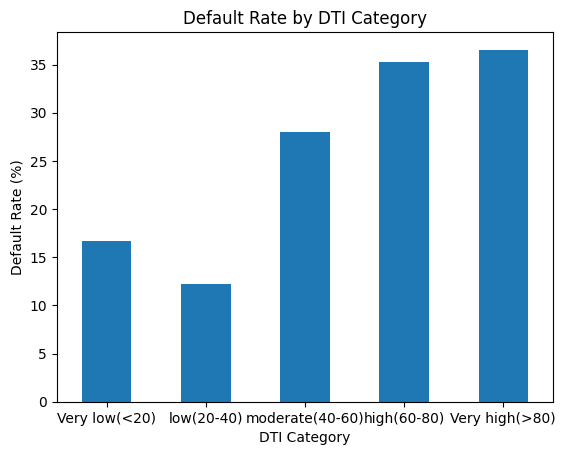

In [41]:
dti_default.plot(kind='bar')

plt.title('Default Rate by DTI Category')
plt.xlabel('DTI Category')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

CREDIT SCORE vs DEFAULT RATE

In [44]:
# First I need to merge the defaulted column from the l table to the b table.
b_credit=b.merge(l[['borrower_id','defaulted']],
                   on='borrower_id',
                   how='inner')



b_credit['credit_score_category']=pd.cut(
    b_credit['credit_score'],
    bins=[-np.inf, 600,650,700,750,np.inf],
    labels=['Poor(<600)',
            'Fair(600-650)',
            'Good(650-700)',
            'Very good(700-750)',
            'Excellent(>750)']
)

credit_score_default=(b_credit.groupby('credit_score_category',observed=True)['defaulted']
                        .mean().mul(100))

credit_score_default

credit_score_category
Poor(<600)            49.152542
Fair(600-650)         28.260870
Good(650-700)         28.205128
Very good(700-750)    15.294118
Excellent(>750)       11.842105
Name: defaulted, dtype: float64

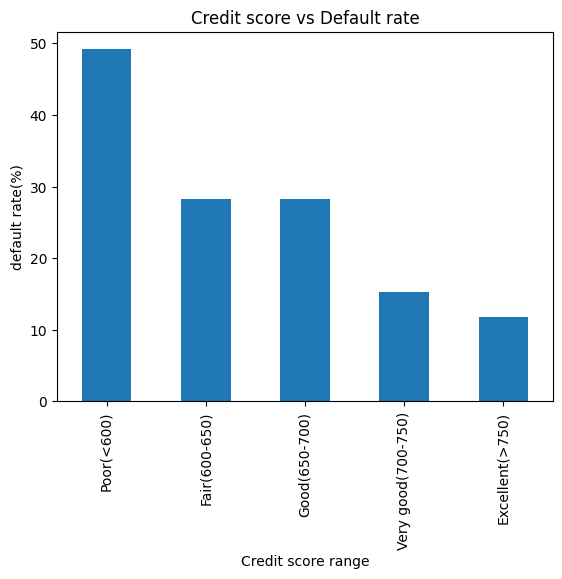

In [48]:
credit_score_default.plot(kind='bar')
plt.title("Credit score vs Default rate")
plt.xlabel("Credit score range")
plt.ylabel("default rate(%)")
plt.xticks(rotation=90)
plt.show()

CORRELATION Between Numeric Columns

In [49]:
# Merging credit score column from b table to the l table

loan_data= l.merge(b[["borrower_id","credit_score"]],
                      on="borrower_id",
                      how="left")

numeric_cols= loan_data.select_dtypes(include='number')

correlation=numeric_cols.corr()

correlation

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted,credit_score
loan_amount,1.000000,-0.030101,-0.002563,0.677752,0.398808,-0.002030,0.018116,-0.003482
term_months,-0.030101,1.000000,-0.039608,-0.591513,-0.455627,-0.006487,-0.034632,0.034330
interest_rate,-0.002563,-0.039608,1.000000,0.062513,0.103792,0.201014,0.198930,-0.755153
monthly_payment,0.677752,-0.591513,0.062513,1.000000,0.665915,0.027357,0.061867,-0.054645
dti_ratio,0.398808,-0.455627,0.103792,0.665915,1.000000,0.169833,0.192454,-0.121115
days_delinquent,-0.002030,-0.006487,0.201014,0.027357,0.169833,1.000000,0.881093,-0.266843
defaulted,0.018116,-0.034632,0.198930,0.061867,0.192454,0.881093,1.000000,-0.286394
credit_score,-0.003482,0.034330,-0.755153,-0.054645,-0.121115,-0.266843,-0.286394,1.000000


In [50]:
correlation['defaulted'].sort_values(ascending=False)

defaulted          1.000000
days_delinquent    0.881093
interest_rate      0.198930
dti_ratio          0.192454
monthly_payment    0.061867
loan_amount        0.018116
term_months       -0.034632
credit_score      -0.286394
Name: defaulted, dtype: float64

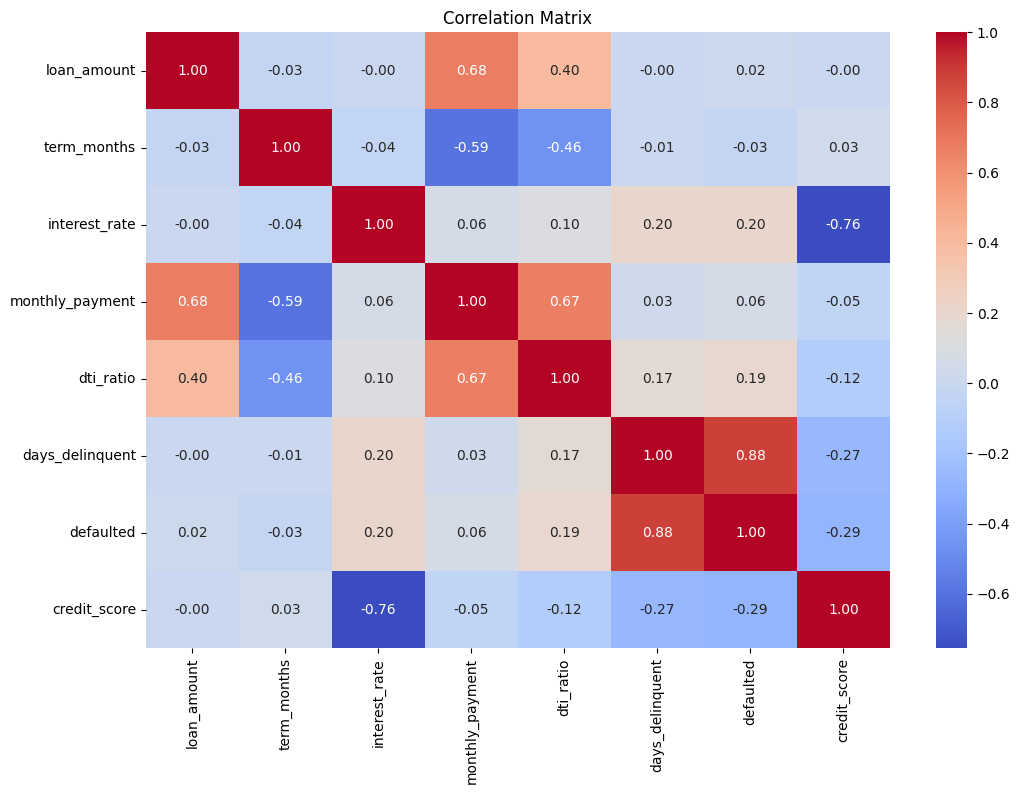

In [51]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

DTI+Credit score vs Default rate

In [52]:
loan_data['credit_category'] = pd.cut(
    loan_data['credit_score'],
    bins=[-np.inf, 600, 650, 700, 750, np.inf],
    labels=[
        'Poor',
        'Fair',
        'Good',
        'Very Good',
        'Excellent'
    ]
)

loan_data['dti_category'] = pd.cut(
    loan_data['dti_ratio'],
    bins=[-np.inf, 20, 40, 60, 80, np.inf],
    labels=[
        'Very Low',
        'Low',
        'Moderate',
        'High',
        'Very High'
    ]
)


# Group by both categories
credit_dti_default = (
    loan_data
    .groupby(
        ['credit_category', 'dti_category'],
        observed=True
    )['defaulted']
    .mean()
    .mul(100)
    .unstack()
)
credit_dti_default

dti_category,Very Low,Low,Moderate,High,Very High
credit_category,,,,,
Poor,11.111111,34.782609,51.282051,62.962963,60.000000
Fair,20.000000,11.111111,36.666667,38.095238,50.000000
Good,28.571429,8.333333,34.615385,46.666667,33.333333
Very Good,11.111111,12.121212,8.695652,30.769231,28.571429
Excellent,15.384615,7.317073,16.000000,13.953488,6.666667


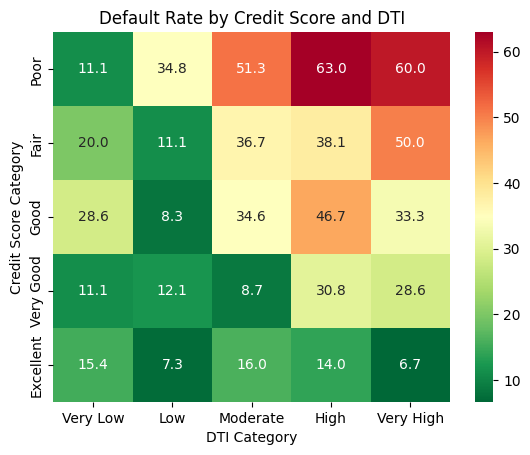

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    credit_dti_default,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r'
)

plt.xlabel('DTI Category')
plt.ylabel('Credit Score Category')
plt.title('Default Rate by Credit Score and DTI')
plt.show()

MERGE BOTH DATASETS

In [57]:
# Merge loans and borrower profiles on 'borrower_id'
df = pd.merge(l, b, on = 'borrower_id', how = 'inner')

df.head()
#df.shape

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,...,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,credit_score_category
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,...,CT,High School,Self-Employed,6,31020,596,Rent,1,892,Poor(<600)
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,...,CT,High School,Self-Employed,6,31020,596,Rent,1,892,Poor(<600)
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,...,CO,High School,Full-Time,4,40188,543,Own,2,869,Poor(<600)
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,...,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806,Fair(600-650)
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,...,TX,High School,Full-Time,19,35036,701,Mortgage,2,928,Very good(700-750)


In [ ]:
# Credit rating segmentation 
score_bins = [0, 579, 639, 699, 749, 850]
score_labels = ['<580 (Poor)', '580-639 (Fair)', '640-699 (Good)', '700-749 (Very Good)', '750+ (Excellent)']
df['credit_score_group'] = pd.cut(df['credit_score'], bins=score_bins, labels=score_labels)

# Debt burden segmentation
dti_max = df['dti_ratio'].max()
if dti_max <= 1.0:
    dti_bins = [0, 0.20, 0.35, 0.50, 1.0]
else:
    dti_bins = [0, 20, 35, 50, 100]

dti_labels = ['<20% (Low)', '20-35% (Moderate)', '35-50% (High)', '>50% (Critical)']
df['dti_group'] = pd.cut(df['dti_ratio'], bins=dti_bins, labels=dti_labels)

In [59]:
# Credit score risk analysis
score_analysis = df.groupby('credit_score_group', observed=False).agg(
    total_loans=('loan_id', 'count'),
    defaulted_loans=('defaulted', 'sum'),
    default_rate_pct=('defaulted', lambda x: x.mean() * 100)
).reset_index()

print("Risk Breakdown by Credit Score")
print(score_analysis)

print('-' * 30)

# DTE (Debt-To-Income) risk analysis
dti_analysis = df.groupby('dti_group', observed=False).agg(
    total_loans=('loan_id', 'count'),
    defaulted_loans=('defaulted', 'sum'),
    default_rate_pct=('defaulted', lambda x: x.mean() * 100)
).reset_index()

print("Risk Breakdown by DTI")
print(dti_analysis)

Risk Breakdown by Credit Score
    credit_score_group  total_loans  defaulted_loans  default_rate_pct
0          <580 (Poor)           74               32         43.243243
1       580-639 (Fair)          117               49         41.880342
2       640-699 (Good)           93               24         25.806452
3  700-749 (Very Good)           86               14         16.279070
4     750+ (Excellent)          231               27         11.688312
------------------------------
Risk Breakdown by DTI
           dti_group  total_loans  defaulted_loans  default_rate_pct
0         <20% (Low)           48                8         16.666667
1  20-35% (Moderate)          133               14         10.526316
2      35-50% (High)          150               31         20.666667
3    >50% (Critical)          248               85         34.274194


In [60]:
df['loan_income_ratio'] = (
    df['loan_amount'] / df['annual_income']
)

df['loan_income_ratio'].describe()

count    601.000000
mean       0.381106
std        0.241186
min        0.023113
25%        0.192439
50%        0.336920
75%        0.523649
max        1.199097
Name: loan_income_ratio, dtype: float64

In [61]:
df.groupby('defaulted')['loan_income_ratio'].mean()

defaulted
0    0.371309
1    0.411639
Name: loan_income_ratio, dtype: float64

Create a Combined Risk Score

In [62]:
df['credit_risk'] = np.where(
    df['credit_score'] < 650, 1, 0
)

df['dti_risk'] = np.where(
    df['dti_ratio'] > 60, 1, 0
)

df['loan_income_risk'] = np.where(
    df['loan_income_ratio'] > 1.5, 1, 0
)

df['delinquency_risk'] = np.where(
    df['days_delinquent'] > 30, 1, 0
)

In [63]:
df['risk_score'] = (
    df['credit_risk']
    + df['dti_risk']
    + df['loan_income_risk']
    + df['delinquency_risk']
)

In [64]:
df.groupby('risk_score')['defaulted'].agg(
    ['count', 'sum', 'mean']
)

risk_analysis = (
    df.groupby('risk_score')['defaulted']
    .agg(['count', 'sum', 'mean'])
)

risk_analysis['default_rate_pct'] = (
    risk_analysis['mean'] * 100
)

risk_analysis

,count,sum,mean,default_rate_pct
risk_score,,,,
0,253,0,0.000000,0.000000
1,209,40,0.191388,19.138756
2,100,67,0.670000,67.000000
3,39,39,1.000000,100.000000


STATISTICAL TESTING

In [65]:
from scipy.stats import pointbiserialr

corr, p_value = pointbiserialr(
    df['credit_score'],
    df['defaulted']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.28639376908202774
P-value: 8.254506277100554e-13


Credit score has a statistically significant negative relationship with loan default (r = -0.286, p < 0.001), indicating that borrowers with higher credit scores tend to have lower default risk.

In [66]:
corr, p_value = pointbiserialr(
    df['dti_ratio'],
    df['defaulted']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.19245414949940792
P-value: 2.006692293367311e-06


DTI ratio has a statistically significant positive relationship with loan default (r = 0.192, p < 0.001), indicating that borrowers with higher DTI ratios tend to have a higher likelihood of default.

In [67]:
df['loan_purpose'].unique()

array(['Vacation', 'Major Purchase', 'Moving', 'Auto Loan', 'Education',
       'Medical Expenses', 'Home Improvement', 'Business Loan',
       'Debt Consolidation', 'Wedding'], dtype=object)

FEATURE ENGINEERING

In [68]:
df.dtypes

loan_id                          object
borrower_id                      object
application_date         datetime64[ns]
loan_purpose                     object
loan_amount                     float64
term_months                       int64
interest_rate                   float64
monthly_payment                 float64
dti_ratio                       float64
loan_status                      object
days_delinquent                   int64
defaulted                         int64
dti category                   category
age                               int64
state                            object
education_level                  object
employment_status                object
years_employed                    int64
annual_income                     int64
credit_score                      int64
home_ownership                   object
dependents                        int64
existing_monthly_debt             int64
credit_score_category          category
credit_score_group             category


In [69]:
df['loan_status'].value_counts()


Current     239
Default     146
Paid Off    113
Late        103
Name: loan_status, dtype: int64

In [70]:
numeric_features = [
    'loan_amount',
    'term_months',
    'interest_rate',
    'monthly_payment',
    'dti_ratio',
    'age',
    'years_employed',
    'annual_income',
    'credit_score',
    'dependents',
    'existing_monthly_debt',
    'loan_income_ratio'
]

categorical_features = [
    'loan_purpose',
    'state',
    'education_level',
    'employment_status',
    'home_ownership'
]

features = numeric_features + categorical_features

X = df[features]
y = df['defaulted']

In [83]:
print(X.shape)
print(y.shape)

(601, 17)
(601,)


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [75]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]
)

In [77]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['loan_amount', 'term_months',
                                                   'interest_rate',
                                                   'monthly_payment',
                                                   'dti_ratio', 'age',
                                                   'years_employed',
                                                   'annual_income',
                                                   'credit_score', 'dependents',
                                                   'existing_monthly_debt',
                                                   'loan_income_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['loan_purpose', 'state',
                                                   'education_level',
                                                   'employment_status',
                                                   'home_ownership'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [78]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [79]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

print(classification_report(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

              precision    recall  f1-score   support

           0       0.82      0.63      0.71        92
           1       0.32      0.55      0.41        29

    accuracy                           0.61       121
   macro avg       0.57      0.59      0.56       121
weighted avg       0.70      0.61      0.64       121

ROC-AUC: 0.6570464767616192


In [80]:
df['loan_status'].value_counts()

Current     239
Default     146
Paid Off    113
Late        103
Name: loan_status, dtype: int64

In [81]:
df[features].isnull().sum()

loan_amount              0
term_months              0
interest_rate            0
monthly_payment          0
dti_ratio                0
age                      0
years_employed           0
annual_income            0
credit_score             0
dependents               0
existing_monthly_debt    0
loan_income_ratio        0
loan_purpose             0
state                    0
education_level          0
employment_status        0
home_ownership           0
dtype: int64

In [82]:
df['defaulted'].value_counts(normalize=True) * 100

0    75.707155
1    24.292845
Name: defaulted, dtype: float64

In [84]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[58 34]
 [13 16]]


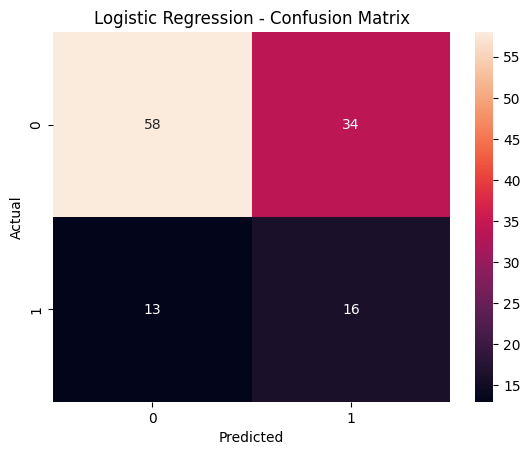

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()